In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from keras.utils import load_img, img_to_array
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import roc_auc_score, roc_curve
from tensorflow.keras.applications import VGG16
from tensorflow.keras.regularizers import l2
import os
import warnings
warnings.filterwarnings('ignore')

2025-12-28 12:57:34.704546: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766926655.077376      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766926655.186746      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766926656.124957      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766926656.125005      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766926656.125008      55 computation_placer.cc:177] computation placer alr

In [2]:
def analyze_images(path):

    folder = path

    widths, heights = [], []

    for root, dirs, files in os.walk(folder):
        for fname in files:
            try:
                img_path = os.path.join(root, fname)
                img = Image.open(img_path)
                w, h = img.size
                widths.append(w)
                heights.append(h)
            except:
                pass

    print("Images Counted:", len(widths))
    if widths and heights:
        print("Smallest widths:", min(widths), " ,Smallest heights:", min(heights))
        print("Biggest widths:", max(widths), " , Biggest heights:", max(heights))
        print("Average widths:", np.mean(widths))
        print("Average heights:", np.mean(heights))
    else:
        print("No images collected. Check the path.")

analyze_images('/kaggle/input/chest-xray-pneumonia')

Images Counted: 11712
Smallest widths: 384  ,Smallest heights: 127
Biggest widths: 2916  , Biggest heights: 2713
Average widths: 1327.880806010929
Average heights: 970.6890368852459


Original image format: JPEG
Image mode: L
(Height, Width, Layers): (1317, 1857, 1)


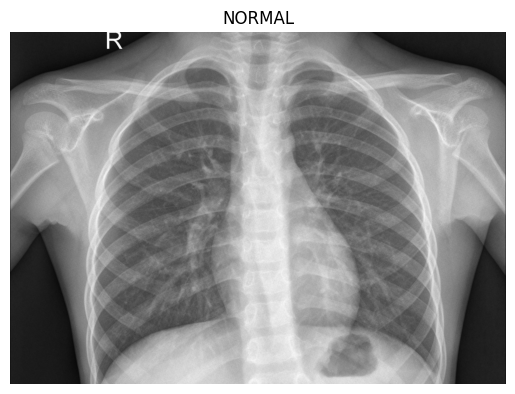

In [4]:
def show_a_sample_with_layers(path):
    from PIL import Image
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    img = Image.open(path)
    img_array = np.array(img)

    width = img.size[0]
    height = img.size[1]

    if len(img_array.shape) == 2:
        layers = 1
    else:
        layers = img_array.shape[2]

    print(f"Original image format: {img.format}")
    print(f"Image mode: {img.mode}")
    print(f"(Height, Width, Layers): ({height}, {width}, {layers})")

    plt.imshow(img, cmap='gray')
    plt.axis("off")
    plt.grid(False)
    plt.title('NORMAL')
    plt.show()

show_a_sample_with_layers('/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0001-0001.jpeg')

In [5]:
import os

def check_class_balance(path):
    """Counts files in each subdirectory of a given path to check for class balance."""

    class_counts = {}
    print(f"Checking balance for: {path}\n")

    try:
        # Get class names (subdirectories)
        class_names = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]

        if not class_names:
            print("No class subdirectories found in this path.")
            return

        print("Class Counts:")
        # Loop through each class, count files, and store in the dictionary
        for class_name in class_names:
            class_path = os.path.join(path, class_name)
            # Count the number of files in the directory
            count = len(os.listdir(class_path))
            class_counts[class_name] = count
            print(f"- {class_name}: {count} images")

        # --- Check for Imbalance ---
        counts = list(class_counts.values())
        if len(counts) > 1:
            min_count = min(counts)
            max_count = max(counts)

            # A common rule of thumb: imbalance exists if the largest class
            # is more than double the size of the smallest class.
            if max_count > min_count * 2:
                print("\nResult: The dataset is *imbalanced*.")
            else:
                print("\nResult: The dataset is *relatively balanced*.")
        else:
            print("\nResult: Only one class found, cannot check balance.")

    except FileNotFoundError:
        print(f"Error: Path not found: {path}")
    except Exception as e:
        print(f"An error occurred: {e}")

# --- Run the check ---
train_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
check_class_balance(train_path)

# It's also good practice to check your test set
print("\n" + "="*30 + "\n")
test_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'
check_class_balance(test_path)

Checking balance for: /kaggle/input/chest-xray-pneumonia/chest_xray/train

Class Counts:
- PNEUMONIA: 3875 images
- NORMAL: 1341 images

Result: The dataset is *imbalanced*.


Checking balance for: /kaggle/input/chest-xray-pneumonia/chest_xray/test

Class Counts:
- PNEUMONIA: 390 images
- NORMAL: 234 images

Result: The dataset is *relatively balanced*.


# **<span style="color:white">Data Preprocessing</span>**

In [6]:
IMG_SIZE =(150, 150)
BATCH_SIZE = 32

In [7]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [8]:
# Define paths
train_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
val_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/val'
test_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'

In [9]:
# Check dataset structure
print("Training set:")
for folder in os.listdir(train_dir):
    print(f"{folder}: {len(os.listdir(os.path.join(train_dir, folder)))} images")

print("\nTest set:")
for folder in os.listdir(test_dir):
    print(f"{folder}: {len(os.listdir(os.path.join(test_dir, folder)))} images")


Training set:
PNEUMONIA: 3875 images
NORMAL: 1341 images

Test set:
PNEUMONIA: 390 images
NORMAL: 234 images


In [10]:
# Data preprocessing and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2  # Use 20% of training data for validation
)

In [11]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [12]:
# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,  # Standard size for pre-trained models
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)
ros = RandomOverSampler(random_state=42)

Found 4173 images belonging to 2 classes.


In [13]:
class_weight_dict = {0: 1.5, 1: 1.0}

In [14]:
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 1043 images belonging to 2 classes.


In [15]:
val_datagen = ImageDataGenerator(rescale=1./255)

In [16]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


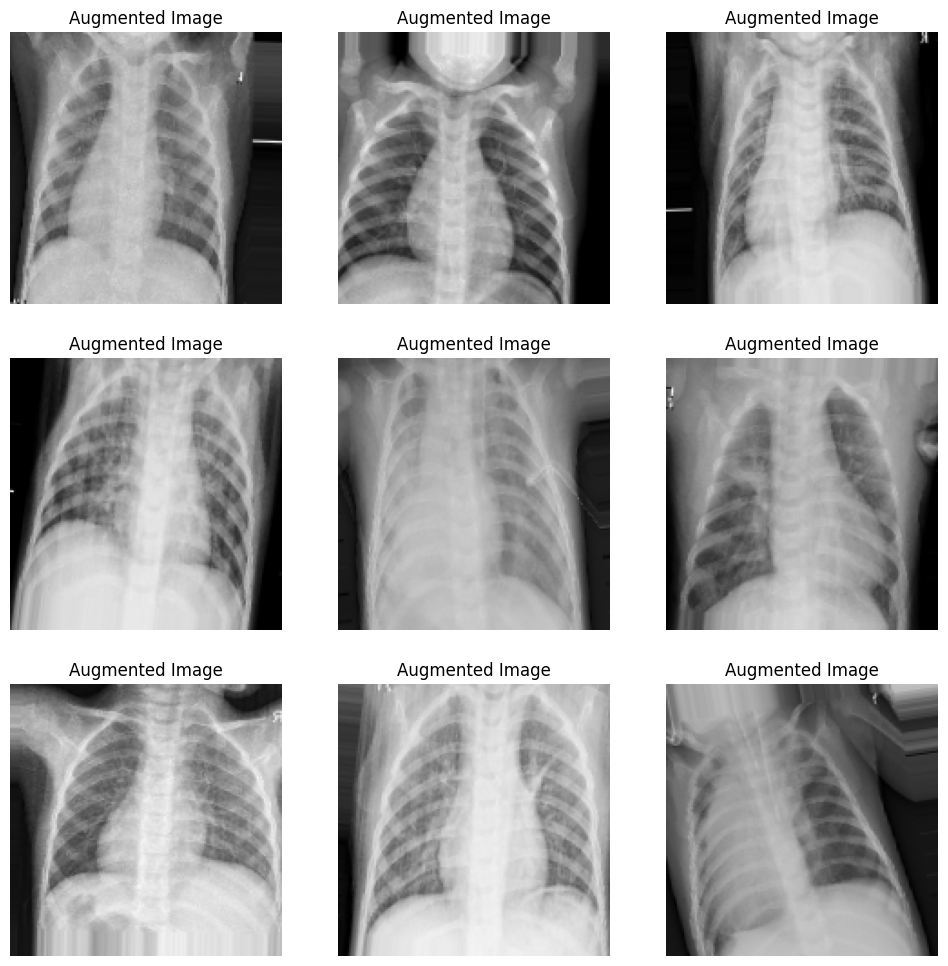

In [17]:
# Take 1 batch from the generator
x_batch, y_batch = next(train_generator)

plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    plt.title("Augmented Image")
    plt.axis("off")

plt.show()


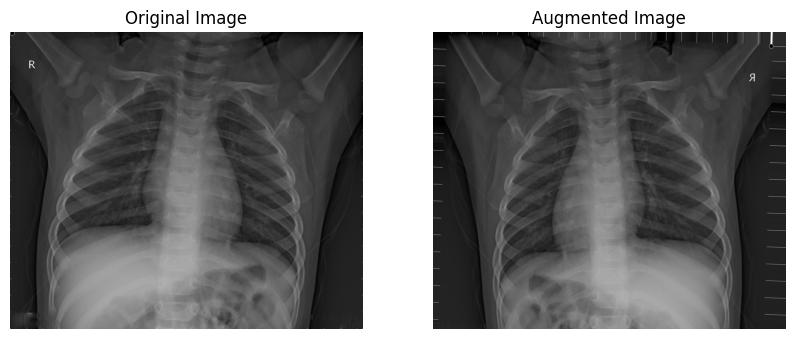

In [18]:
# Pick any image path (example from NORMAL folder)
img_path = train_dir + "/NORMAL/" + os.listdir(train_dir + "/NORMAL")[0]

# Load original
original = load_img(img_path)
original_arr = img_to_array(original) / 255.0

# Augmented version (generated from ImageDataGenerator)
augmented = train_datagen.random_transform(original_arr)

# Plot
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original_arr)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(augmented)
plt.title("Augmented Image")
plt.axis("off")

plt.show()


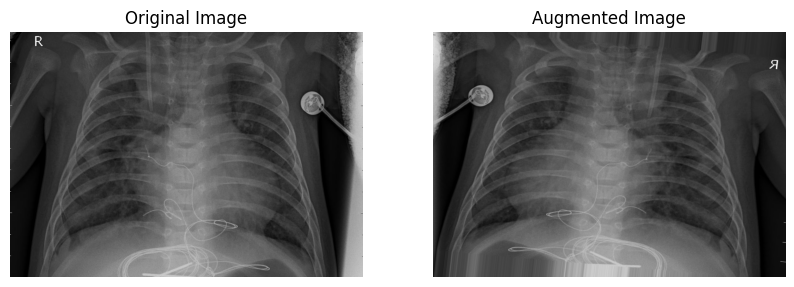

In [19]:
# Pick any image path (example from NORMAL folder)
img_path = train_dir + "/PNEUMONIA/" + os.listdir(train_dir + "/PNEUMONIA")[0]

# Load original
original = load_img(img_path)
original_arr = img_to_array(original) / 255.0

# Augmented version (generated from ImageDataGenerator)
augmented = train_datagen.random_transform(original_arr)

# Plot
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original_arr)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(augmented)
plt.title("Augmented Image")
plt.axis("off")

plt.show()


# Building CNN Model

In [ ]:
def create_light_model():
    base_model = MobileNetV2( weights = '/kaggle/input/mobilenetv2weights/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5',
                             include_top=False,
                             input_shape=(150, 150, 3))
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),  # faster then flaten
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

model, base_model = create_light_model()

In [27]:
import tensorflow.keras.backend as K
import tensorflow as tf

def focal_loss(alpha=0.3, gamma=2.0):
    def loss(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())
        pt = tf.where(K.equal(y_true, 1), y_pred, 1 - y_pred)
        return -K.mean(alpha * K.pow(1. - pt, gamma) * K.log(pt))
    return loss


In [28]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=focal_loss(alpha=0.3, gamma=2),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)


In [29]:
# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_150            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [30]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
]

In [31]:
# Train the model
steps_per_epoch = min(100, train_generator.samples // BATCH_SIZE)  
val_steps = val_generator.samples // BATCH_SIZE

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch, 
    epochs=20,  
    validation_data=val_generator,
    validation_steps=val_steps,
    callbacks=callbacks,
    class_weight=class_weight_dict,  
    verbose=1
)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 106s 996ms/step - accuracy: 0.4267 - loss: 0.6246 - precision: 0.7951 - recall: 0.3044 - val_accuracy: 0.4697 - val_loss: 0.3363 - val_precision: 0.9819 - val_recall: 0.2870 - learning_rate: 1.0000e-05
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 431ms/step - accuracy: 0.4441 - loss: 0.5944 - precision: 0.8160 - recall: 0.3239 - val_accuracy: 0.4561 - val_loss: 0.3393 - val_precision: 0.9761 - val_recall: 0.2698 - learning_rate: 1.0000e-05
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 91s 918ms/step - accuracy: 0.4679 - loss: 0.5641 - precision: 0.8470 - recall: 0.3562 - val_accuracy: 0.5244 - val_loss: 0.3383 - val_precision: 0.9927 - val_recall: 0.3585 - learning_rate: 1.0000e-05
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 415ms/step - accuracy: 0.4909 - loss: 0.5571 - precision: 0.8716 - recall: 0.3719 - val_accuracy: 0.5381 - val_loss: 0.3376 - val_precision: 0.9797 - val_recall: 0.3823 - learning_rate: 1.0000e-05
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━

In [33]:
# Fine-Tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [34]:
model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [35]:
print("Fine-Tuning: Training top + last 10 layers...")
model.summary()  

Fine-Tuning: Training top + last 10 layers...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_150            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 1,693,057 (6.46 MB)

 Non-trainable params: 734,144 (2.80 MB)

In [36]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True), 
    ModelCheckpoint('best_finetuned_model.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-7)
]

In [39]:
fine_tune_epochs = 20  
history_fine = model.fit(
    train_generator,
    epochs=fine_tune_epochs,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 137s 966ms/step - accuracy: 0.6193 - loss: 1.2089 - precision_2: 0.8811 - recall_2: 0.5601 - val_accuracy: 0.7833 - val_loss: 0.7010 - val_precision_2: 0.9911 - val_recall_2: 0.7148 - learning_rate: 5.0000e-06
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 126s 960ms/step - accuracy: 0.6871 - loss: 1.0800 - precision_2: 0.9224 - recall_2: 0.6336 - val_accuracy: 0.8111 - val_loss: 0.6828 - val_precision_2: 0.9932 - val_recall_2: 0.7510 - learning_rate: 5.0000e-06
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 121s 925ms/step - accuracy: 0.7234 - loss: 0.9592 - precision_2: 0.9322 - recall_2: 0.6755 - val_accuracy: 0.8265 - val_loss: 0.6383 - val_precision_2: 0.9983 - val_recall_2: 0.7677 - learning_rate: 5.0000e-06
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 119s 909ms/step - accuracy: 0.7632 - loss: 0.8738 - precision_2: 0.9488 - recall_2: 0.7203 - val_accuracy: 0.8217 - val_loss: 0.6744 - val_precision_2: 0.9966 - val_recall_2: 0.7626 - learning_rate: 5.0000e-06


In [40]:
history.history['accuracy'] += history_fine.history['accuracy']
history.history['val_accuracy'] += history_fine.history['val_accuracy']

## Model Evaluation

In [41]:
# Evaluate on test set
test_loss, test_acc, test_precision, test_recall = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 466ms/step - accuracy: 0.8813 - loss: 0.5552 - precision_2: 0.5228 - recall_2: 0.6311

Test Accuracy: 0.9119
Test Precision: 0.9056
Test Recall: 0.9590


In [42]:
# Predict on test set
y_pred = (model.predict(test_generator) > 0.5).astype("int32")
y_true = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 486ms/step


In [43]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.92      0.83      0.88       234
   PNEUMONIA       0.91      0.96      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.90      0.90       624
weighted avg       0.91      0.91      0.91       624



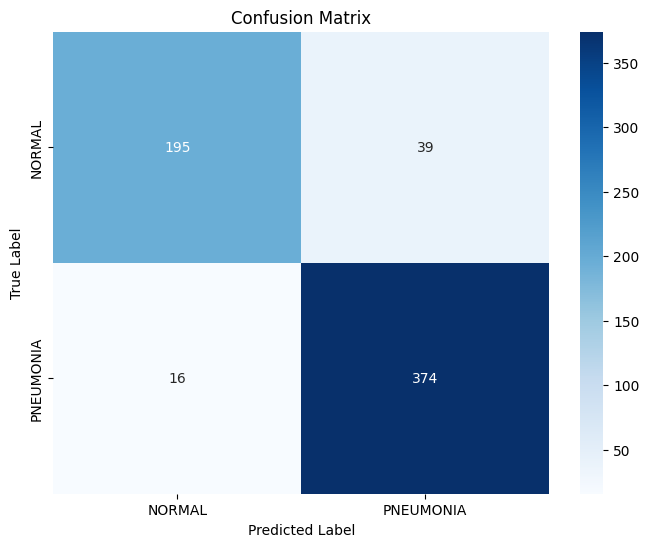

In [44]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [47]:
# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)
plt.tight_layout()
plt.show()
# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


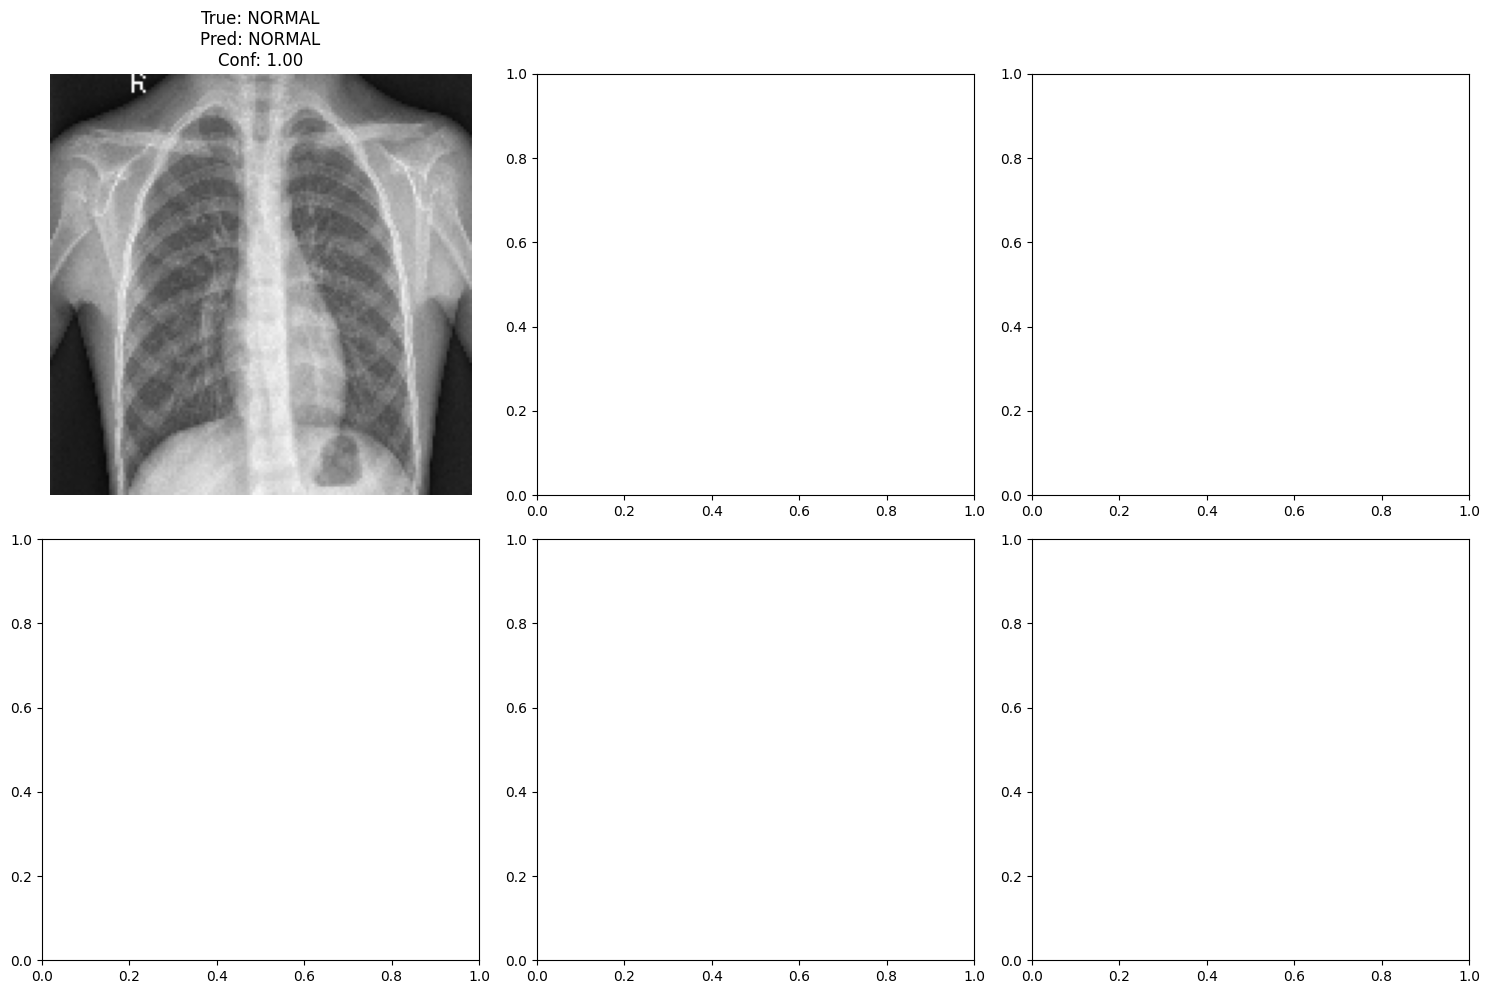

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


<Figure size 640x480 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


<Figure size 640x480 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


<Figure size 640x480 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


<Figure size 640x480 with 0 Axes>

Model saved as 'pneumonia_detection_model.keras


In [ ]:
# Function to visualize predictions
def visualize_predictions(num_images=6):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    test_generator.reset()
    x_batch, y_batch = next(test_generator)

    for i in range(num_images):
        img = x_batch[i]
        true_label = 'PNEUMONIA' if y_batch[i] == 1 else 'NORMAL'

        # Predict
        pred = model.predict(np.expand_dims(img, axis=0))
        pred_label = 'PNEUMONIA' if pred[0] > 0.5 else 'NORMAL'
        confidence = pred[0][0] if pred[0] > 0.5 else 1 - pred[0][0]

        axes[i].imshow(img)
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

visualize_predictions()

# Save the final model
model.save('pneumonia_detection_model.keras')
print("Model saved as 'pneumonia_detection_model.keras")

In [49]:
# Load the saved model (as in the image: model.h5)
model = load_model('best_finetuned_model.keras')

#  Prepare test generator
test_dir  = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [50]:
results = model.evaluate(test_generator, verbose=1)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 452ms/step - accuracy: 0.8813 - loss: 0.5552 - precision_2: 0.5228 - recall_2: 0.6311
loss: 0.48297783732414246
compile_metrics: 0.9118589758872986


In [65]:
#  Generate predictions (probabilities)
probs = model.predict(test_generator, verbose=1)
y_pred = (probs.ravel() >= 0.6).astype(int)
y_true = test_generator.classes
class_indices = test_generator.class_indices
idx_to_class = {v:k for k,v in class_indices.items()}

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 462ms/step


In [66]:
#   ( Accuracy, Precision, Recall, F1-score )
print("\n--- Metrics on test set ---")
print("Accuracy (sklearn):", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall:", recall_score(y_true, y_pred, zero_division=0))
print("F1-score:", f1_score(y_true, y_pred, zero_division=0))


--- Metrics on test set ---
Accuracy (sklearn): 0.9134615384615384
Precision: 0.917910447761194
Recall: 0.9461538461538461
F1-score: 0.9318181818181818


In [67]:
#  classification report (precision/recall/f1 per class)
target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.91      0.86      0.88       234
   PNEUMONIA       0.92      0.95      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.90      0.91       624
weighted avg       0.91      0.91      0.91       624




Confusion Matrix:
 [[201  33]
 [ 21 369]]


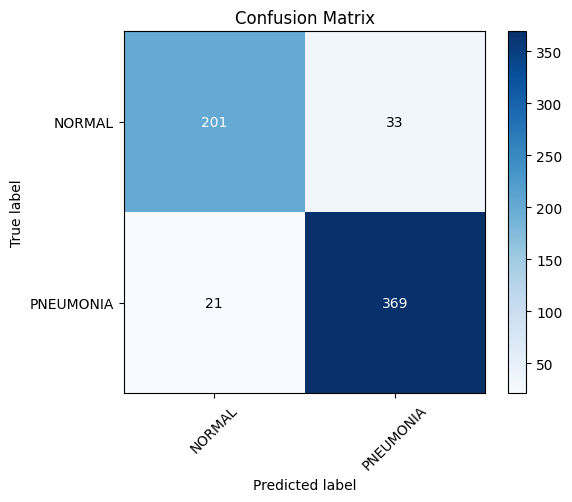

In [68]:
# Target names
target_names = ['NORMAL', 'PNEUMONIA']

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)
plt.ylabel('True label')
plt.xlabel('Predicted label')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha="center", va="center",
                 color="white" if cm[i,j] > cm.max()/2 else "black")

plt.tight_layout()
plt.show()

In [69]:

#  Identify misclassified sample
filenames = test_generator.filenames
errors_idx = np.where(y_pred != y_true)[0]
print("\nMisclassified samples count:", len(errors_idx))



Misclassified samples count: 54


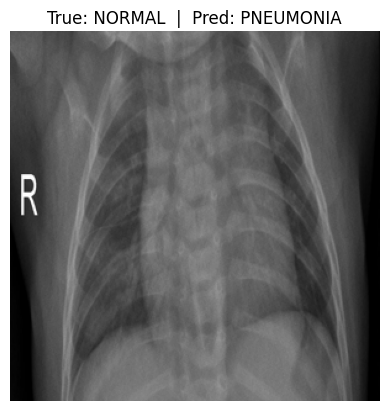

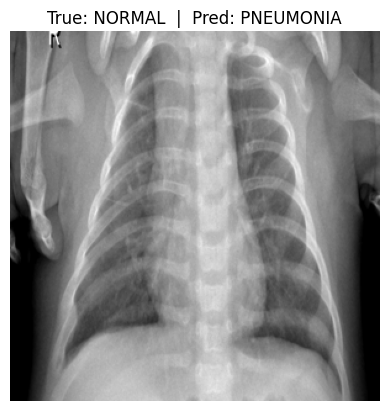

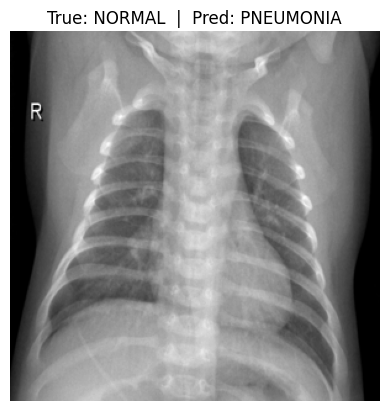

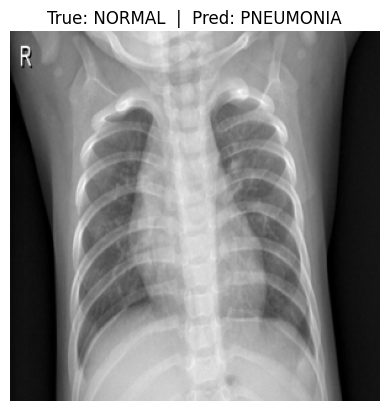

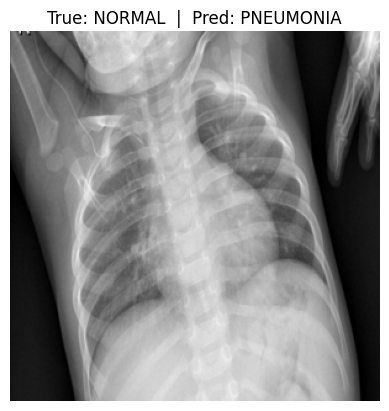

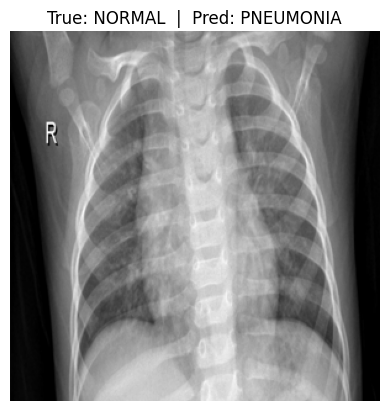

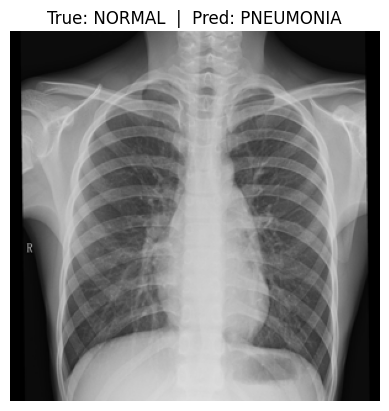

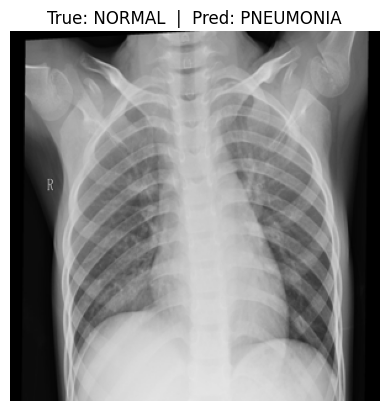

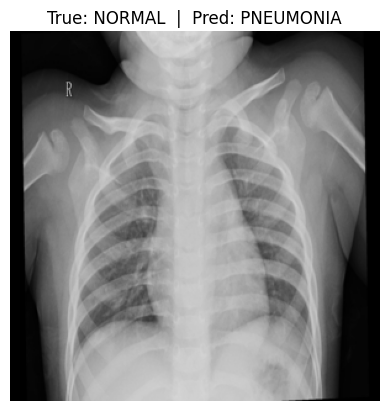

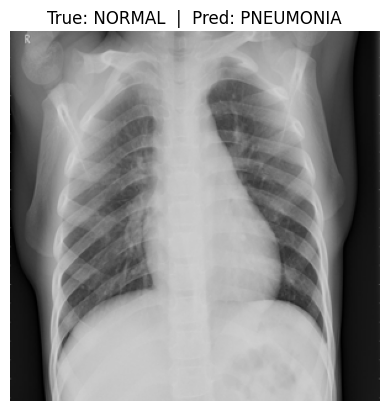

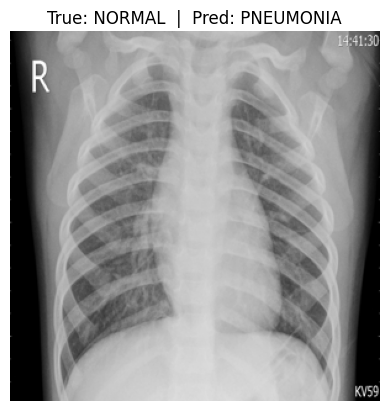

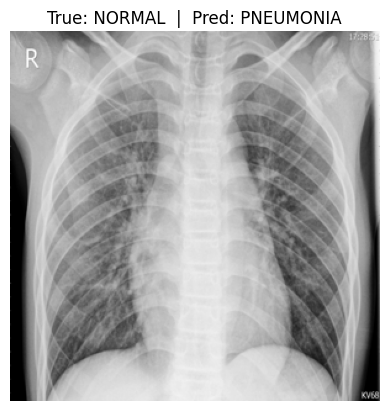

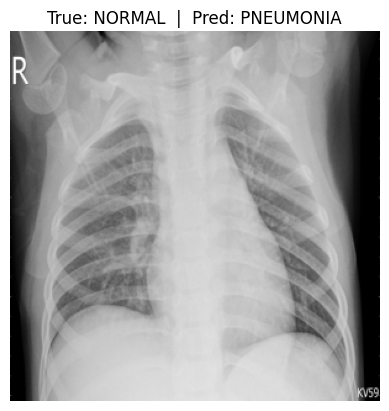

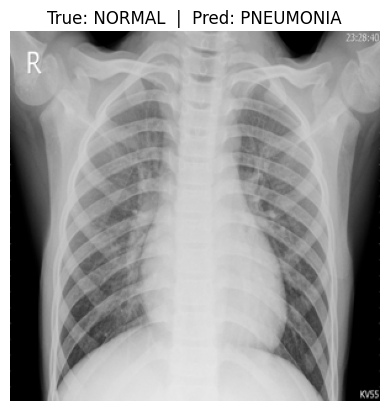

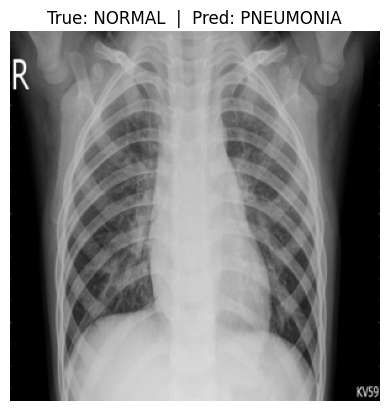

In [70]:
for idx in errors_idx[:15]:
    rel_path = filenames[idx]
    img_path = os.path.join(test_dir, rel_path)
    img = Image.open(img_path).convert('RGB')
    display_img = img.resize((300,300))
    plt.figure()
    plt.imshow(display_img)
    plt.axis('off')
    true_label = idx_to_class[int(y_true[idx])]
    pred_label = idx_to_class[int(y_pred[idx])]
    plt.title(f"True: {true_label}  |  Pred: {pred_label}")
    plt.show()

In [71]:
# Predictions
y_pred_proba = model.predict(test_generator)
y_pred = (y_pred_proba > 0.5).astype(int)
y_true = test_generator.classes
# ROC-AUC
auc_score = roc_auc_score(y_true, y_pred_proba)
print(f"ROC-AUC: {auc_score:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 490ms/step
ROC-AUC: 0.9668


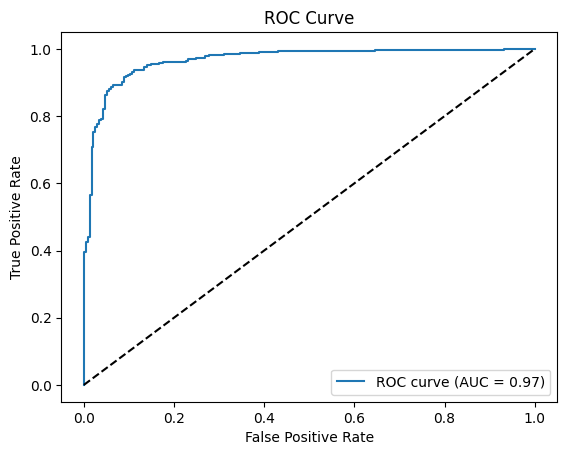

In [72]:
# Plot ROC
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()